# Genre Prediction Pipeline
## TMDB + IMDB Merged Movies Dataset

This notebook performs end-to-end data cleaning, exploration, feature analysis, and genre prediction using multiple Naive Bayes variants with cross-validation and grid search.

---

In [69]:
# --- Configuration ---
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Paths
DATA_DIR = Path('./data')
RESULTS_DIR = Path('./results')
RESULTS_DIR.mkdir(exist_ok=True)

# File configuration
FILE_CONFIG = {
    'TMDB IMDB Movies Dataset': {
        'filename': 'TMDB IMDB Movies Dataset.csv',
        'column_mappings': {
            'original_title': 'title',
            # 'vote_average': 'averageRating',
            # 'vote_count': 'numVotes',
        }
    },
    'merged_dataset': {
        'filename': 'merged_dataset.csv',
        'column_mappings': {
            'name': 'title',
            'rating': 'vote_average',
            'num_raters': 'vote_count',
            'run_length': 'runtime',
            'year': 'release_date'
        }
    }
}

# Columns to drop (no predictive value)
USELESS_COLS = ['id', 'backdrop_path', 'poster_path', 'homepage', 'tconst', 'original_title']

# Numeric columns to standardise
NUMERIC_COLS = [
    'vote_average', 'vote_count', 'revenue', 'runtime', 'budget',
    'popularity', 'averageRating', 'numVotes', 'num_reviews'
]

# Boolean columns
BOOLEAN_COLS = ['adult']

# List-like columns
LIST_LIKE_COLS = [
    'genres', 'production_companies', 'production_countries',
    'spoken_languages', 'keywords', 'directors', 'writers', 'cast'
]

# Empty-value threshold
EMPTY_COL_THRESHOLD = 0.8
EMPTY_ALIASES = ['unknown', 'unset', '', 'nan', 'none', 'n/a', 'na']

print("Configuration loaded.")

Configuration loaded.


## 1. Load & Merge Datasets

In [70]:
# Load datasets and apply column mappings
dfs = []
for dataset_name, config in FILE_CONFIG.items():
    filepath = DATA_DIR / config['filename']
    print(f"Loading {filepath}...")
    df_temp = pd.read_csv(filepath, low_memory=False)
    print(f"  Shape: {df_temp.shape}")
    print(f"  Columns: {list(df_temp.columns)}")

    # Rename columns to standardised names
    df_temp.rename(columns=config['column_mappings'], inplace=True)

    # Drop duplicate columns (keep first occurrence)
    df_temp = df_temp.loc[:, ~df_temp.columns.duplicated()]

    df_temp['_source'] = dataset_name
    dfs.append(df_temp)

# Merge datasets
df = pd.concat(dfs, ignore_index=True)
print(f"\nMerged shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Loading data\TMDB IMDB Movies Dataset.csv...
  Shape: (435435, 29)
  Columns: ['id', 'title', 'vote_average', 'vote_count', 'status', 'release_date', 'revenue', 'runtime', 'adult', 'backdrop_path', 'budget', 'homepage', 'tconst', 'original_language', 'original_title', 'overview', 'popularity', 'poster_path', 'tagline', 'genres', 'production_companies', 'production_countries', 'spoken_languages', 'keywords', 'directors', 'writers', 'averageRating', 'numVotes', 'cast']
Loading data\merged_dataset.csv...
  Shape: (1500, 9)
  Columns: ['name', 'year', 'movie_rated', 'run_length', 'genres', 'release_date', 'rating', 'num_raters', 'num_reviews']

Merged shape: (436935, 31)
Columns: ['id', 'title', 'vote_average', 'vote_count', 'status', 'release_date', 'revenue', 'runtime', 'adult', 'backdrop_path', 'budget', 'homepage', 'tconst', 'original_language', 'overview', 'popularity', 'poster_path', 'tagline', 'genres', 'production_companies', 'production_countries', 'spoken_languages', 'keywords', 

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,spoken_languages,keywords,directors,writers,averageRating,numVotes,cast,_source,movie_rated,num_reviews
0,27205.0,Inception,8.364,34495,Released,2010-07-15,8.255328e+08,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,"English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc...",Christopher Nolan,Christopher Nolan,8.8,2784846.0,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W...",TMDB IMDB Movies Dataset,NaN,NaN
1,157336.0,Interstellar,8.417,32571,Released,2014-11-05,7.017292e+08,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,English,"rescue, future, spacecraft, race against time,...",Christopher Nolan,"Jonathan Nolan, Christopher Nolan",8.7,2476729.0,"Matthew McConaughey, Anne Hathaway, Michael Ca...",TMDB IMDB Movies Dataset,NaN,NaN
2,155.0,The Dark Knight,8.512,30619,Released,2008-07-16,1.004558e+09,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,"English, Mandarin","joker, sadism, chaos, secret identity, crime f...",Christopher Nolan,"Jonathan Nolan, Christopher Nolan, David S. Go...",9.1,3132056.0,"Christian Bale, Heath Ledger, Aaron Eckhart, M...",TMDB IMDB Movies Dataset,NaN,NaN
3,19995.0,Avatar,7.573,29815,Released,2009-12-15,2.923706e+09,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,"English, Spanish","future, society, culture clash, space travel, ...",James Cameron,James Cameron,7.9,1484844.0,"Sam Worthington, Zoe Saldaña, Sigourney Weaver...",TMDB IMDB Movies Dataset,NaN,NaN
4,24428.0,The Avengers,7.710,29166,Released,2012-04-25,1.518816e+09,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,"English, Hindi, Russian","new york city, superhero, shield, based on com...",Joss Whedon,"Joss Whedon, Zak Penn",8.0,1546016.0,"Robert Downey Jr., Chris Evans, Mark Ruffalo, ...",TMDB IMDB Movies Dataset,NaN,NaN


## 2. Standardise Column Names

In [71]:
def standardise_column_names(df):
    """Lowercase, strip, replace spaces/special chars with underscores."""
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(r'[\s\-\.]+', '_', regex=True)
        .str.replace(r'[^a-z0-9_]', '', regex=True)
    )
    return df

df = standardise_column_names(df)
print("Columns after standardisation:")
print(list(df.columns))

Columns after standardisation:
['id', 'title', 'vote_average', 'vote_count', 'status', 'release_date', 'revenue', 'runtime', 'adult', 'backdrop_path', 'budget', 'homepage', 'tconst', 'original_language', 'overview', 'popularity', 'poster_path', 'tagline', 'genres', 'production_companies', 'production_countries', 'spoken_languages', 'keywords', 'directors', 'writers', 'averagerating', 'numvotes', 'cast', '_source', 'movie_rated', 'num_reviews']


## 3. Drop Useless Columns

In [72]:
# Standardise the useless column names to match our cleaned names
useless_standardised = [
    c.strip().lower().replace(' ', '_').replace('-', '_').replace('.', '_')
    for c in USELESS_COLS
]

cols_before = set(df.columns)
df.drop(columns=[c for c in useless_standardised if c in df.columns], inplace=True)
dropped = cols_before - set(df.columns)
print(f"Dropped {len(dropped)} columns: {dropped}")
print(f"Remaining: {df.shape[1]} columns")

Dropped 5 columns: {'backdrop_path', 'poster_path', 'homepage', 'tconst', 'id'}
Remaining: 26 columns


## 4. Drop Highly Empty Columns (threshold=0.8)

Considers NaN, empty strings, `'unknown'`, and `'unset'` as empty values.

In [73]:
def calc_empty_ratio(series):
    """Calculate the ratio of empty values (NaN + alias values)."""
    is_empty = series.isna()
    if series.dtype == object:
        str_vals = series.astype(str).str.strip().str.lower()
        is_empty = is_empty | str_vals.isin(EMPTY_ALIASES)
    return is_empty.mean()

empty_ratios = df.apply(calc_empty_ratio)
highly_empty = empty_ratios[empty_ratios >= EMPTY_COL_THRESHOLD]

print(f"Columns with >= {EMPTY_COL_THRESHOLD*100:.0f}% empty values:")
for col, ratio in highly_empty.sort_values(ascending=False).items():
    print(f"  {col}: {ratio:.1%}")

df.drop(columns=highly_empty.index, inplace=True)
print(f"\nDropped {len(highly_empty)} columns. Remaining: {df.shape[1]}")

Columns with >= 80% empty values:
  movie_rated: 99.7%
  num_reviews: 99.7%

Dropped 2 columns. Remaining: 24


## 5. Standardise All String Data
- Lowercase, strip whitespace
- Unify NaN representations
- Truncate trailing delimiters (`;`, `,`)

In [74]:
def standardise_strings(df):
    """Standardise all object columns: lowercase, strip, unify NaNs, truncate trailing chars."""
    for col in df.select_dtypes(include='object').columns:
        # Convert to string, strip, lowercase
        df[col] = df[col].astype(str).str.strip().str.lower()

        # Unify NaN aliases
        df[col] = df[col].replace(EMPTY_ALIASES, np.nan)

        # Truncate trailing delimiters (; , | )
        df[col] = df[col].str.rstrip(';,| ')

        # Also strip leading delimiters
        df[col] = df[col].str.lstrip(';,| ')

    return df

df = standardise_strings(df)
print("String standardisation complete.")
df.head()

String standardisation complete.


,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,budget,original_language,...,production_companies,production_countries,spoken_languages,keywords,directors,writers,averagerating,numvotes,cast,_source
0,inception,8.364,34495,released,2010-07-15,8.255328e+08,148,false,160000000.0,en,...,"legendary pictures, syncopy, warner bros. pict...","united kingdom, united states of america","english, french, japanese, swahili","rescue, mission, dream, airplane, paris, franc...",christopher nolan,christopher nolan,8.8,2784846.0,"leonardo dicaprio, joseph gordon-levitt, ken w...",tmdb imdb movies dataset
1,interstellar,8.417,32571,released,2014-11-05,7.017292e+08,169,false,165000000.0,en,...,"legendary pictures, syncopy, lynda obst produc...","united kingdom, united states of america",english,"rescue, future, spacecraft, race against time,...",christopher nolan,"jonathan nolan, christopher nolan",8.7,2476729.0,"matthew mcconaughey, anne hathaway, michael ca...",tmdb imdb movies dataset
2,the dark knight,8.512,30619,released,2008-07-16,1.004558e+09,152,false,185000000.0,en,...,"dc comics, legendary pictures, syncopy, isobel...","united kingdom, united states of america","english, mandarin","joker, sadism, chaos, secret identity, crime f...",christopher nolan,"jonathan nolan, christopher nolan, david s. go...",9.1,3132056.0,"christian bale, heath ledger, aaron eckhart, m...",tmdb imdb movies dataset
3,avatar,7.573,29815,released,2009-12-15,2.923706e+09,162,false,237000000.0,en,...,"dune entertainment, lightstorm entertainment, ...","united states of america, united kingdom","english, spanish","future, society, culture clash, space travel, ...",james cameron,james cameron,7.9,1484844.0,"sam worthington, zoe saldaña, sigourney weaver...",tmdb imdb movies dataset
4,the avengers,7.710,29166,released,2012-04-25,1.518816e+09,143,false,220000000.0,en,...,marvel studios,united states of america,"english, hindi, russian","new york city, superhero, shield, based on com...",joss whedon,"joss whedon, zak penn",8.0,1546016.0,"robert downey jr., chris evans, mark ruffalo, ...",tmdb imdb movies dataset


## 6. Drop Rows with Empty Genres

In [75]:
rows_before = len(df)
df = df[df['genres'].notna() & (df['genres'].str.strip() != '')]
rows_after = len(df)
print(f"Dropped {rows_before - rows_after} rows with empty genres.")
print(f"Remaining: {rows_after} rows")

Dropped 79148 rows with empty genres.
Remaining: 357787 rows


## 7. Standardise Numeric Columns

In [76]:
def standardise_numeric(df, numeric_cols):
    """Convert numeric columns to proper numeric types, coerce errors to NaN."""
    present_cols = [c for c in numeric_cols if c in df.columns]
    for col in present_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    print(f"Standardised {len(present_cols)} numeric columns: {present_cols}")
    missing = [c for c in numeric_cols if c not in df.columns]
    if missing:
        print(f"Not found (skipped): {missing}")
    return df

df = standardise_numeric(df, NUMERIC_COLS)
df[[ c for c in NUMERIC_COLS if c in df.columns]].describe()

Standardised 6 numeric columns: ['vote_average', 'vote_count', 'revenue', 'runtime', 'budget', 'popularity']
Not found (skipped): ['averageRating', 'numVotes', 'num_reviews']


,vote_average,vote_count,revenue,runtime,budget,popularity
count,357787.000000,3.577870e+05,3.562870e+05,356287.00000,3.562870e+05,356287.000000
mean,3.993646,1.785285e+03,2.018517e+06,70.51525,7.880990e+05,2.528840
std,3.063906,3.364194e+04,2.893123e+07,63.72619,8.167624e+06,12.502505
min,0.000000,0.000000e+00,0.000000e+00,0.00000,0.000000e+00,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,24.00000,0.000000e+00,0.600000
50%,5.000000,2.000000e+00,0.000000e+00,84.00000,0.000000e+00,1.004000
75%,6.400000,8.000000e+00,0.000000e+00,97.00000,0.000000e+00,1.966500
max,10.000000,2.258845e+06,2.923706e+09,14400.00000,8.880000e+08,2994.357000


## 8. Standardise Boolean Columns

In [77]:
def standardise_boolean(df, bool_cols):
    """Convert boolean columns to 0/1 integers."""
    for col in bool_cols:
        if col not in df.columns:
            print(f"  {col} not found, skipping.")
            continue
        # Handle various representations
        df[col] = (
            df[col].astype(str).str.strip().str.lower()
            .map({'true': 1, 'false': 0, '1': 1, '0': 0, '1.0': 1, '0.0': 0, 'yes': 1, 'no': 0})
        )
        df[col] = df[col].fillna(0).astype(int)
        print(f"  {col}: {df[col].value_counts().to_dict()}")
    return df

df = standardise_boolean(df, BOOLEAN_COLS)

  adult: {0: 353945, 1: 3842}


## 9. Clean List-like Columns

### Strategy for handling list-like columns without exploding the feature space

**Problem:** One-hot encoding list-like columns (cast, keywords, etc.) can create thousands of features, making mutual information / correlation analysis impractical.

**Solutions implemented below (pick the one that fits your needs):**

1. **Count encoding** — Replace the list with its *length* (e.g., number of genres, number of cast members). Simple, preserves cardinality signal, no dimensionality explosion. *Good for correlation analysis.*

2. **Top-N binary encoding** — For each list-like column, keep only the top N most frequent values as binary columns. E.g., for `production_companies`, create `is_warner_bros`, `is_universal`, etc. *Controllable dimensionality.*

3. **Target-mean encoding** — For each unique value in a list-like column, compute the mean target frequency. Replace the list with the average of those means. *Single feature per column, preserves predictive power, but risk of leakage — use with CV.*

Below we implement **option 1 (count)** for the correlation analysis, and **option 2 (top-N binary)** as optional features for modeling. Option 3 is available as a function if you want to experiment.

In [78]:
def parse_list_column(series):
    """Parse a list-like string column (comma or semicolon separated) into actual lists."""
    def _parse(val):
        if pd.isna(val):
            return []
        val = str(val).strip()
        if not val:
            return []
        # Split on comma or semicolon
        items = [item.strip() for item in val.replace(';', ',').split(',')]
        return [item for item in items if item and item not in EMPTY_ALIASES]
    return series.apply(_parse)

# Parse all list-like columns that exist
existing_list_cols = [c for c in LIST_LIKE_COLS if c in df.columns]
for col in existing_list_cols:
    df[f'{col}_parsed'] = parse_list_column(df[col])
    df[f'{col}_count'] = df[f'{col}_parsed'].apply(len)
    print(f"  {col}: parsed, median list length = {df[f'{col}_count'].median():.0f}, "
          f"max = {df[f'{col}_count'].max()}")

print(f"\nParsed {len(existing_list_cols)} list-like columns.")

  genres: parsed, median list length = 1, max = 11
  production_companies: parsed, median list length = 1, max = 30
  production_countries: parsed, median list length = 1, max = 59
  spoken_languages: parsed, median list length = 1, max = 20
  keywords: parsed, median list length = 0, max = 96
  directors: parsed, median list length = 1, max = 145
  writers: parsed, median list length = 1, max = 121
  cast: parsed, median list length = 8, max = 14

Parsed 8 list-like columns.


In [79]:
def top_n_binary_encoding(df, col_parsed, top_n=10, prefix=None):
    """Create binary columns for the top N most frequent values in a parsed list column."""
    if prefix is None:
        prefix = col_parsed.replace('_parsed', '')

    # Flatten all values and count frequencies
    from collections import Counter
    all_values = [v for lst in df[col_parsed] for v in lst]
    top_values = [val for val, _ in Counter(all_values).most_common(top_n)]

    for val in top_values:
        safe_val = val.replace(' ', '_').replace('-', '_')[:30]
        df[f'{prefix}_{safe_val}'] = df[col_parsed].apply(lambda lst: int(val in lst))

    return df, top_values

# Example: you can enable this for specific columns
# df, top_genres = top_n_binary_encoding(df, 'genres_parsed', top_n=15, prefix='genre')
print("top_n_binary_encoding() is available. Call it on any parsed list column.")

top_n_binary_encoding() is available. Call it on any parsed list column.


In [80]:
def target_mean_encoding(df, col_parsed, target_col, fallback=0.0):
    """
    Mean-target encode a list-like column.
    For each unique value, compute its average association with each target class.
    Replace the list with the mean of those associations.
    WARNING: Use only within cross-validation to avoid leakage.
    """
    from collections import defaultdict

    # Build value -> mean target mapping
    value_targets = defaultdict(list)
    for lst, target in zip(df[col_parsed], df[target_col]):
        for val in lst:
            value_targets[val].append(target)

    # For genre prediction, we use frequency of the most common target per value
    value_scores = {}
    for val, targets in value_targets.items():
        value_scores[val] = len(set(targets))  # diversity score

    col_name = col_parsed.replace('_parsed', '') + '_target_encoded'
    df[col_name] = df[col_parsed].apply(
        lambda lst: np.mean([value_scores.get(v, fallback) for v in lst]) if lst else fallback
    )
    return df

print("target_mean_encoding() is available for experimentation.")

target_mean_encoding() is available for experimentation.


## 10. Profile Unique Values

In [81]:
def profile_unique_values(df, list_parsed_cols=None):
    """
    Returns a DataFrame with column profiling info:
    - column, dtype, unique_count, category (numeric/categorical/textual/list-like)
    - details: min-max for numeric; median element count + max list length for list-like
    - example: a sample value
    """
    if list_parsed_cols is None:
        list_parsed_cols = [c for c in df.columns if c.endswith('_parsed')]

    rows = []
    for col in df.columns:
        if col in list_parsed_cols or col.endswith('_parsed'):
            continue  # Skip parsed helper columns

        unique_count = df[col].nunique()
        example = df[col].dropna().iloc[0] if df[col].notna().any() else None

        # Determine category
        parsed_col = f'{col}_parsed'
        if parsed_col in df.columns:
            category = 'list-like'
            lengths = df[parsed_col].apply(len)
            details = f"median_elements={lengths.median():.0f}, max_length={lengths.max()}"
        elif pd.api.types.is_numeric_dtype(df[col]):
            category = 'numeric'
            details = f"min={df[col].min():.2f}, max={df[col].max():.2f}"
        elif unique_count <= 50:
            category = 'categorical'
            top3 = df[col].value_counts().head(3).index.tolist()
            details = f"top3={top3}"
        else:
            category = 'textual'
            avg_len = df[col].astype(str).str.len().mean()
            details = f"avg_str_len={avg_len:.0f}"

        rows.append({
            'column': col,
            'dtype': str(df[col].dtype),
            'unique_count': unique_count,
            'non_null': df[col].notna().sum(),
            'null_pct': f"{df[col].isna().mean():.1%}",
            'category': category,
            'details': details,
            'example': str(example)[:80] if example is not None else 'NaN'
        })

    profile_df = pd.DataFrame(rows)
    return profile_df

profile = profile_unique_values(df)
profile.style.set_properties(**{'text-align': 'left'})

,column,dtype,unique_count,non_null,null_pct,category,details,example
0,title,str,305900,357784,0.0%,textual,avg_str_len=18,inception
1,vote_average,float64,4992,357787,0.0%,numeric,"min=0.00, max=10.00",8.364
2,vote_count,int64,4878,357787,0.0%,numeric,"min=0.00, max=2258845.00",34495
3,status,str,6,356287,0.4%,categorical,"top3=['released', 'post production', 'in production']",released
4,release_date,str,38297,353078,1.3%,textual,avg_str_len=10,2010-07-15
5,revenue,float64,13476,356287,0.4%,numeric,"min=0.00, max=2923706026.00",825532764.0
6,runtime,float64,512,356287,0.4%,numeric,"min=0.00, max=14400.00",148.0
7,adult,int64,2,357787,0.0%,numeric,"min=0.00, max=1.00",0
8,budget,float64,3871,356287,0.4%,numeric,"min=0.00, max=888000000.00",160000000.0
9,original_language,str,155,356287,0.4%,textual,avg_str_len=2,en


## 11. Rating Coverage Analysis
Compare coverage of TMDB ratings (`vote_average`, `vote_count`) vs IMDB ratings (`averagerating`, `numvotes`).

In [82]:
# Identify the rating columns (names are lowercased after standardisation)
tmdb_avg = 'vote_average' if 'vote_average' in df.columns else None
tmdb_cnt = 'vote_count' if 'vote_count' in df.columns else None
imdb_avg = 'averagerating' if 'averagerating' in df.columns else None
imdb_cnt = 'numvotes' if 'numvotes' in df.columns else None

# Check which columns actually exist
rating_cols = {
    'tmdb_avg': tmdb_avg, 'tmdb_cnt': tmdb_cnt,
    'imdb_avg': imdb_avg, 'imdb_cnt': imdb_cnt
}
print("Rating columns found:")
for k, v in rating_cols.items():
    if v:
        non_null = df[v].notna().sum()
        print(f"  {k} ({v}): {non_null} non-null ({non_null/len(df):.1%})")
    else:
        print(f"  {k}: NOT FOUND")

Rating columns found:
  tmdb_avg (vote_average): 357787 non-null (100.0%)
  tmdb_cnt (vote_count): 357787 non-null (100.0%)
  imdb_avg (averagerating): 356287 non-null (99.6%)
  imdb_cnt (numvotes): 356287 non-null (99.6%)


,category,count,pct
0,Both TMDB & IMDB,356287,99.6%
1,Only TMDB,1500,0.4%
2,Only IMDB,0,0.0%
3,Neither,0,0.0%


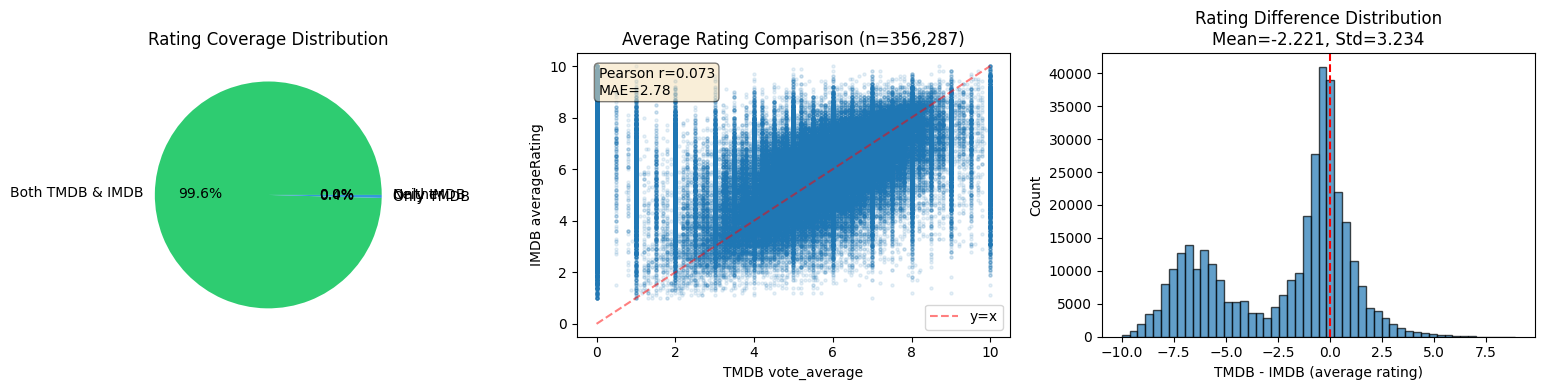

In [83]:
# Coverage analysis
if tmdb_avg and imdb_avg:
    has_tmdb = df[tmdb_avg].notna() & df[tmdb_cnt].notna()
    has_imdb = df[imdb_avg].notna() & df[imdb_cnt].notna()

    both = has_tmdb & has_imdb
    only_tmdb = has_tmdb & ~has_imdb
    only_imdb = ~has_tmdb & has_imdb
    neither = ~has_tmdb & ~has_imdb

    coverage = pd.DataFrame({
        'category': ['Both TMDB & IMDB', 'Only TMDB', 'Only IMDB', 'Neither'],
        'count': [both.sum(), only_tmdb.sum(), only_imdb.sum(), neither.sum()],
        'pct': [both.mean(), only_tmdb.mean(), only_imdb.mean(), neither.mean()]
    })
    coverage['pct'] = coverage['pct'].apply(lambda x: f"{x:.1%}")
    display(coverage)

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Pie chart of coverage
    axes[0].pie(coverage['count'], labels=coverage['category'], autopct='%1.1f%%',
                colors=['#2ecc71', '#3498db', '#e74c3c', '#95a5a6'])
    axes[0].set_title('Rating Coverage Distribution')

    # For overlapping rows, compare the averages
    overlap_df = df[both].copy()
    if len(overlap_df) > 0:
        axes[1].scatter(overlap_df[tmdb_avg], overlap_df[imdb_avg], alpha=0.1, s=5)
        axes[1].plot([0, 10], [0, 10], 'r--', alpha=0.5, label='y=x')
        axes[1].set_xlabel('TMDB vote_average')
        axes[1].set_ylabel('IMDB averageRating')
        axes[1].set_title(f'Average Rating Comparison (n={len(overlap_df):,})')
        axes[1].legend()

        # Correlation
        corr = overlap_df[[tmdb_avg, imdb_avg]].corr().iloc[0, 1]
        mae = (overlap_df[tmdb_avg] - overlap_df[imdb_avg]).abs().mean()
        axes[1].text(0.05, 0.95, f'Pearson r={corr:.3f}\nMAE={mae:.2f}',
                     transform=axes[1].transAxes, va='top',
                     bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

        # Distribution of difference
        diff = overlap_df[tmdb_avg] - overlap_df[imdb_avg]
        axes[2].hist(diff, bins=50, edgecolor='black', alpha=0.7)
        axes[2].axvline(0, color='red', linestyle='--')
        axes[2].set_xlabel('TMDB - IMDB (average rating)')
        axes[2].set_ylabel('Count')
        axes[2].set_title(f'Rating Difference Distribution\nMean={diff.mean():.3f}, Std={diff.std():.3f}')

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'rating_coverage_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Cannot compare — one or both rating column pairs missing.")
    print("Available columns:", [c for c in df.columns if 'rat' in c or 'vote' in c or 'avg' in c])

## 12. Genre Distribution Analysis

In [84]:
# Parse genres into lists (already done above, but let's use the parsed column)
if 'genres_parsed' not in df.columns:
    df['genres_parsed'] = parse_list_column(df['genres'])

# Overall genre frequency
from collections import Counter

all_genres = [g for lst in df['genres_parsed'] for g in lst]
genre_counts = Counter(all_genres)
genre_freq = pd.DataFrame(genre_counts.most_common(), columns=['genre', 'count'])
genre_freq['pct'] = genre_freq['count'] / len(df) * 100

print(f"Total unique genres: {len(genre_counts)}")
print(f"Total genre assignments: {len(all_genres)}")
print(f"Average genres per movie: {np.mean([len(lst) for lst in df['genres_parsed']]):.2f}")
print()
display(genre_freq)

Total unique genres: 22
Total genre assignments: 607805
Average genres per movie: 1.70



,genre,count,pct
0,drama,140238,39.195946
1,comedy,91734,25.639277
2,documentary,59345,16.586684
3,romance,36095,10.088405
4,thriller,33295,9.305816
5,action,31882,8.910888
6,horror,30506,8.526302
7,animation,25702,7.183604
8,crime,24798,6.930939
9,tv movie,18012,5.034280


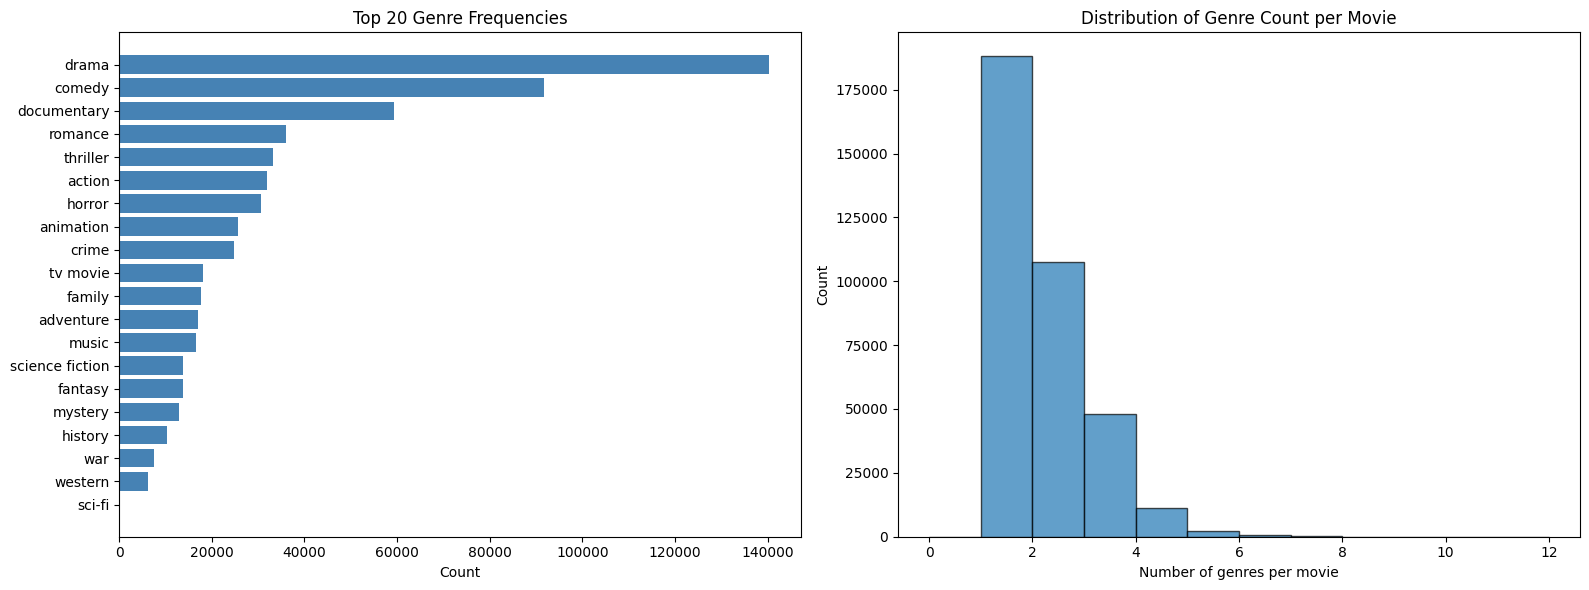

In [85]:
# Visualise genre distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart of genre frequency
top_20 = genre_freq.head(20)
axes[0].barh(top_20['genre'][::-1], top_20['count'][::-1], color='steelblue')
axes[0].set_xlabel('Count')
axes[0].set_title('Top 20 Genre Frequencies')

# Distribution of number of genres per movie
genre_lengths = df['genres_parsed'].apply(len)
axes[1].hist(genre_lengths, bins=range(0, genre_lengths.max() + 2), edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Number of genres per movie')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Genre Count per Movie')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'genre_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [86]:
# Genre position analysis
# For movies with multiple genres, in which position does each genre typically appear?

genre_positions = {}
for lst in df['genres_parsed']:
    for pos, genre in enumerate(lst):
        if genre not in genre_positions:
            genre_positions[genre] = []
        genre_positions[genre].append(pos)

position_stats = []
for genre, positions in genre_positions.items():
    position_stats.append({
        'genre': genre,
        'count': len(positions),
        'mean_position': np.mean(positions),
        'median_position': np.median(positions),
        'pct_first': sum(1 for p in positions if p == 0) / len(positions) * 100
    })

position_df = pd.DataFrame(position_stats).sort_values('count', ascending=False)
print("Genre position analysis (when a genre appears in a multi-genre list, what position is it in?):")
print("  pct_first = % of times the genre appears as the first listed genre")
display(position_df.head(20).style.format({
    'mean_position': '{:.2f}',
    'median_position': '{:.1f}',
    'pct_first': '{:.1f}%'
}))

Genre position analysis (when a genre appears in a multi-genre list, what position is it in?):
  pct_first = % of times the genre appears as the first listed genre


,genre,count,mean_position,median_position,pct_first
3,drama,140238,0.39,0.0,68.7%
7,comedy,91734,0.38,0.0,69.4%
18,documentary,59345,0.08,0.0,92.9%
8,romance,36095,0.99,1.0,30.7%
5,thriller,33295,1.03,1.0,34.5%
0,action,31882,0.46,0.0,65.6%
14,horror,30506,0.47,0.0,66.1%
12,animation,25702,0.26,0.0,80.6%
4,crime,24798,0.77,1.0,44.4%
17,tv movie,18012,1.20,1.0,25.8%


## 13. Truncate Genres & Group Rare Genres

In [87]:
def truncate_genres(df, max_genres=1):
    """Keep only the first `max_genres` genre(s) per movie."""
    df = df.copy()
    df['genre_label'] = df['genres_parsed'].apply(
        lambda lst: lst[0] if len(lst) >= 1 else np.nan
    ) if max_genres == 1 else df['genres_parsed'].apply(
        lambda lst: ', '.join(lst[:max_genres]) if lst else np.nan
    )
    before = len(df)
    df = df[df['genre_label'].notna()]
    print(f"truncate_genres(max_genres={max_genres}): kept {len(df)}/{before} rows")
    print(f"Unique genre labels: {df['genre_label'].nunique()}")
    return df

df = truncate_genres(df, max_genres=1)
print("\nGenre label distribution:")
display(df['genre_label'].value_counts())

truncate_genres(max_genres=1): kept 357787/357787 rows
Unique genre labels: 21

Genre label distribution:


genre_label
drama              96358
comedy             63699
documentary        55129
action             20927
animation          20713
horror             20153
thriller           11487
romance            11088
crime              11016
music               7654
adventure           6930
family              5928
science fiction     5065
tv movie            4650
western             4190
fantasy             4083
mystery             3459
war                 2556
history             2532
biography            167
sci-fi                 3
Name: count, dtype: int64

In [88]:
def group_rare_genres(df, genre_col='genre_label', percentile=80):
    """
    Group genres below the given percentile count into 'other'.
    The threshold is the count at the `percentile`-th percentile of genre frequencies.
    """
    df = df.copy()
    counts = df[genre_col].value_counts()
    threshold = np.percentile(counts.values, 100 - percentile)
    rare_genres = counts[counts <= threshold].index.tolist()

    print(f"Threshold (bottom {100-percentile}th percentile): <= {threshold:.0f} occurrences")
    print(f"Rare genres grouped into 'other': {rare_genres}")

    df[genre_col] = df[genre_col].apply(lambda g: 'other' if g in rare_genres else g)
    print(f"\nNew distribution:")
    display(df[genre_col].value_counts())
    return df

# Uncomment the next line to group rare genres:
# df = group_rare_genres(df, genre_col='genre_label', percentile=80)

## 14. Feature Importance — Correlation & Mutual Information

We combine:
- **Numeric correlation** (Pearson/Spearman with encoded target) for numeric features
- **Mutual Information** for all features (handles non-linear relationships)

Using count-encoded list-like columns to keep dimensionality manageable.

In [89]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif

# Prepare features for MI analysis
# Use: numeric cols + count-encoded list cols + boolean cols
feature_candidates = []

# Numeric columns that exist
for col in NUMERIC_COLS:
    if col in df.columns and df[col].notna().sum() > 0:
        feature_candidates.append(col)

# Count-encoded list columns
for col in existing_list_cols:
    count_col = f'{col}_count'
    if count_col in df.columns:
        feature_candidates.append(count_col)

# Boolean columns
for col in BOOLEAN_COLS:
    if col in df.columns:
        feature_candidates.append(col)

print(f"Feature candidates for MI analysis ({len(feature_candidates)}):")
print(feature_candidates)

# Encode target
le_target = LabelEncoder()
df['genre_encoded'] = le_target.fit_transform(df['genre_label'])

# Build feature matrix (fill NaN with median for numeric, 'unset' for text, drop all-NaN cols)
X_mi = df[feature_candidates].copy()

# Drop columns where all values are NaN
all_nan_cols = X_mi.columns[X_mi.isna().all()].tolist()
if all_nan_cols:
    print(f"Dropping all-NaN columns: {all_nan_cols}")
    X_mi.drop(columns=all_nan_cols, inplace=True)
    feature_candidates = [c for c in feature_candidates if c not in all_nan_cols]

for col in X_mi.columns:
    converted = pd.to_numeric(X_mi[col], errors='coerce')
    # If coercion introduced MORE NaNs than original, it's not truly numeric
    if converted.isna().sum() > X_mi[col].isna().sum():
        # Textual/categorical column — fill with 'unset', then label-encode
        X_mi[col] = X_mi[col].fillna('unset').astype(str)
        X_mi[col] = X_mi[col].astype('category').cat.codes
    else:
        X_mi[col] = converted
        X_mi[col].fillna(X_mi[col].median(), inplace=True)

# Final safety check
remaining_nan = X_mi.columns[X_mi.isna().any()].tolist()
if remaining_nan:
    print(f"Warning: filling remaining NaN cols with 0: {remaining_nan}")
    X_mi[remaining_nan] = X_mi[remaining_nan].fillna(0)

y_mi = df['genre_encoded']

# Mutual Information
mi_scores = mutual_info_classif(X_mi, y_mi, random_state=42, n_neighbors=5)
mi_df = pd.DataFrame({
    'feature': feature_candidates,
    'mutual_information': mi_scores
}).sort_values('mutual_information', ascending=False)

print("\nMutual Information scores (top features):")
display(mi_df)

Feature candidates for MI analysis (15):
['vote_average', 'vote_count', 'revenue', 'runtime', 'budget', 'popularity', 'genres_count', 'production_companies_count', 'production_countries_count', 'spoken_languages_count', 'keywords_count', 'directors_count', 'writers_count', 'cast_count', 'adult']

Mutual Information scores (top features):


,feature,mutual_information
13,cast_count,0.172136
3,runtime,0.156848
6,genres_count,0.104810
12,writers_count,0.085388
5,popularity,0.061845
0,vote_average,0.048283
11,directors_count,0.029541
1,vote_count,0.027683
8,production_countries_count,0.019959
9,spoken_languages_count,0.019795


In [91]:
# Feature engineer release_date into year and month
if 'release_date' in df.columns:
    date_raw = df['release_date'].astype(str).str.replace(
        r'\(.*?\)', '', regex=True
    ).str.strip()

    parsed = pd.to_datetime(date_raw, format='%Y-%m-%d', errors='coerce')
    mask = parsed.isna()
    parsed[mask] = pd.to_datetime(date_raw[mask], format='%d %B %Y', errors='coerce')
    mask = parsed.isna()
    parsed[mask] = pd.to_datetime(date_raw[mask], format='mixed', errors='coerce')

    df['release_year'] = parsed.dt.year
    df['release_month'] = parsed.dt.month

    success = parsed.notna().sum()
    total = len(df)
    print(f"Parsed {success}/{total} dates ({success/total:.1%})")
    print(f"  release_year: {df['release_year'].notna().sum()} non-null")
    print(f"  release_month: {df['release_month'].notna().sum()} non-null")

    failed = date_raw[parsed.isna()].unique()[:5]
    if len(failed) > 0:
        print(f"  Sample unparsed values: {failed}")

    df.drop(columns=['release_date'], inplace=True)
else:
    print("release_date not found in columns.")

Parsed 353078/357787 dates (98.7%)
  release_year: 353078 non-null
  release_month: 353078 non-null
  Sample unparsed values: <StringArray>
[nan]
Length: 1, dtype: str


In [92]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif

# Use ALL original columns (numeric, boolean, AND categorical/textual)
# Exclude only helper/engineered columns and the target itself
EXCLUDE_SUFFIXES = ('_count', '_parsed', '_encoded')
EXCLUDE_COLS = {'genre_label', '_source', 'genre_encoded', 'genres', 'title'}

feature_candidates = [
    c for c in df.columns
    if not c.endswith(EXCLUDE_SUFFIXES)
    and c not in EXCLUDE_COLS
]

print(f"Feature candidates (all original columns, {len(feature_candidates)}):")
print(feature_candidates)

# Encode target
le_target = LabelEncoder()
df['genre_encoded'] = le_target.fit_transform(df['genre_label'])

# Build feature matrix
X_mi = df[feature_candidates].copy()

# Drop all-NaN columns
all_nan_cols = X_mi.columns[X_mi.isna().all()].tolist()
if all_nan_cols:
    print(f"Dropping all-NaN columns: {all_nan_cols}")
    X_mi.drop(columns=all_nan_cols, inplace=True)
    feature_candidates = [c for c in feature_candidates if c not in all_nan_cols]

# Track which columns are truly numeric vs categorical (for MI discrete_features param)
discrete_mask = []

for col in X_mi.columns:
    converted = pd.to_numeric(X_mi[col], errors='coerce')
    if converted.isna().sum() > X_mi[col].isna().sum():
        # Categorical/textual — label encode
        X_mi[col] = X_mi[col].fillna('unset').astype(str)
        X_mi[col] = X_mi[col].astype('category').cat.codes
        discrete_mask.append(True)
    else:
        # Numeric — fill NaN with median
        X_mi[col] = converted
        X_mi[col].fillna(X_mi[col].median(), inplace=True)
        discrete_mask.append(False)

remaining_nan = X_mi.columns[X_mi.isna().any()].tolist()
if remaining_nan:
    print(f"Filling remaining NaN cols with 0: {remaining_nan}")
    X_mi[remaining_nan] = X_mi[remaining_nan].fillna(0)

y_mi = df['genre_encoded']

# Mutual Information — pass discrete_features so MI uses the right estimator per column
mi_scores = mutual_info_classif(
    X_mi, y_mi,
    discrete_features=discrete_mask,
    random_state=42,
    n_neighbors=5
)
mi_df = pd.DataFrame({
    'feature': feature_candidates,
    'mutual_information': mi_scores
}).sort_values('mutual_information', ascending=False)

print("\nMutual Information scores (top features):")
display(mi_df)

Feature candidates (all original columns, 21):
['vote_average', 'status', 'revenue', 'runtime', 'adult', 'budget', 'original_language', 'overview', 'popularity', 'tagline', 'production_companies', 'production_countries', 'spoken_languages', 'keywords', 'directors', 'writers', 'averagerating', 'numvotes', 'cast', 'release_year', 'release_month']
Filling remaining NaN cols with 0: ['revenue', 'runtime', 'budget', 'popularity', 'averagerating', 'numvotes', 'release_year', 'release_month']

Mutual Information scores (top features):


,feature,mutual_information
7,overview,2.133143
18,cast,2.122144
15,writers,1.885907
14,directors,1.624312
10,production_companies,1.220987
13,keywords,0.888657
9,tagline,0.592418
11,production_countries,0.185874
12,spoken_languages,0.166165
3,runtime,0.156182


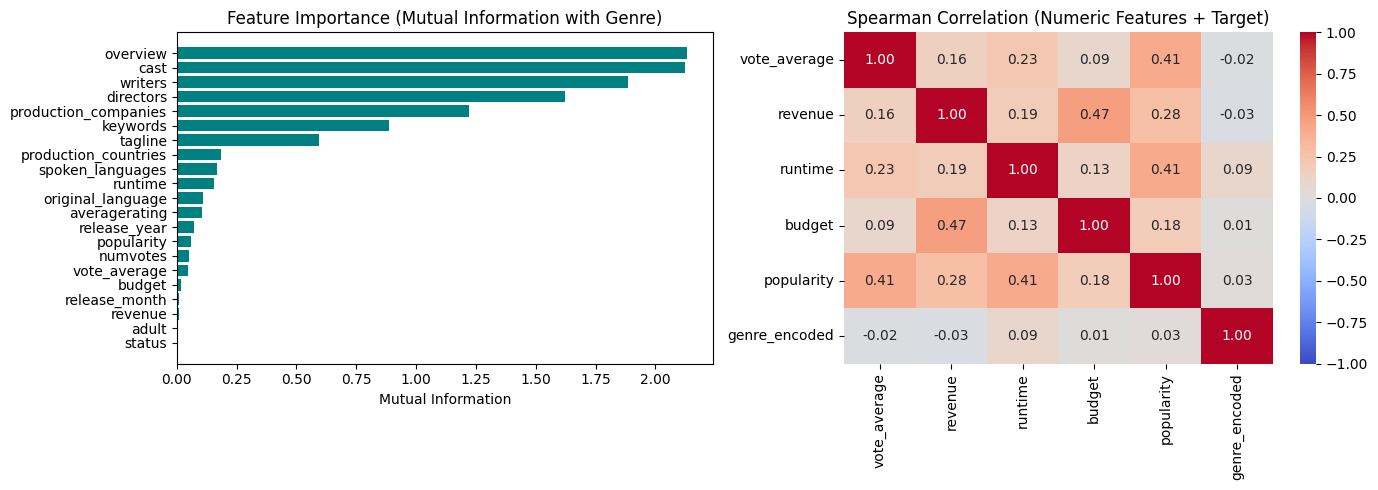

In [93]:
# Visualise MI scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MI bar chart
mi_df_sorted = mi_df.sort_values('mutual_information', ascending=True)
axes[0].barh(mi_df_sorted['feature'], mi_df_sorted['mutual_information'], color='teal')
axes[0].set_xlabel('Mutual Information')
axes[0].set_title('Feature Importance (Mutual Information with Genre)')

# Numeric correlation heatmap (for numeric features only)
numeric_features = [c for c in feature_candidates if c in NUMERIC_COLS and c in df.columns]
if numeric_features:
    corr_cols = numeric_features + ['genre_encoded']
    corr_matrix = df[corr_cols].corr(method='spearman')
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1],
                center=0, vmin=-1, vmax=1)
    axes[1].set_title('Spearman Correlation (Numeric Features + Target)')
else:
    axes[1].text(0.5, 0.5, 'No numeric features available', ha='center', va='center')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [98]:
# Select top 5 features
TOP_N_FEATURES = 5
# top_features = mi_df.head(TOP_N_FEATURES)['feature'].tolist()
top_features = ['runtime', 'averagerating', 'release_year', 'popularity', 'numvotes']
print(f"\nTop {TOP_N_FEATURES} features selected for modeling:")
for i, feat in enumerate(top_features, 1):
    mi_val = mi_df[mi_df['feature'] == feat]['mutual_information'].values[0]
    print(f"  {i}. {feat} (MI={mi_val:.4f})")


Top 5 features selected for modeling:
  1. runtime (MI=0.1562)
  2. averagerating (MI=0.1060)
  3. release_year (MI=0.0728)
  4. popularity (MI=0.0594)
  5. numvotes (MI=0.0528)


## 15. Genre Prediction — Naive Bayes Models

Models:
- **GaussianNB** — continuous features
- **MultinomialNB** — requires non-negative features (we shift if needed)
- **ComplementNB** — designed for imbalanced classes
- **BernoulliNB** — binary features

With cross-validation and grid search.

In [108]:
from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV, StratifiedKFold, learning_curve
)
from sklearn.naive_bayes import GaussianNB, MultinomialNB, ComplementNB, BernoulliNB
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, f1_score, accuracy_score, precision_score,
    confusion_matrix, ConfusionMatrixDisplay
)
import joblib

# Prepare final dataset
X = df[top_features].copy()
y = df['genre_label'].copy()

# Coerce to numeric (label-encode text columns, same logic as MI cell)
for col in X.columns:
    converted = pd.to_numeric(X[col], errors='coerce')
    if converted.isna().sum() > X[col].isna().sum():
        X[col] = X[col].fillna('unset').astype(str)
        X[col] = X[col].astype('category').cat.codes
    else:
        X[col] = converted

# Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Force all columns numeric and impute NaN with median
for col in X_train.columns:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

# Impute with training set medians (avoid data leakage)
train_medians = X_train.median()
X_train = X_train.fillna(train_medians)
X_test = X_test.fillna(train_medians)

# Safety: if any median was NaN (entire column empty), fill with 0
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

assert not X_train.isna().any().any(), f"X_train still has NaN: {X_train.isna().sum()[X_train.isna().any()]}"
assert not X_test.isna().any().any(), f"X_test still has NaN: {X_test.isna().sum()[X_test.isna().any()]}"

print(f"Imputation complete. NaN in X_train: {X_train.isna().sum().sum()}, X_test: {X_test.isna().sum().sum()}")

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"Number of classes: {y.nunique()}")
print(f"Features: {list(X.columns)}")
print(f"NaN per column:\n{X_train.isna().sum()}")

Imputation complete. NaN in X_train: 0, X_test: 0
Training set: 286229 samples
Test set:     71558 samples
Number of classes: 21
Features: ['runtime', 'averagerating', 'release_year', 'popularity', 'numvotes']
NaN per column:
runtime          0
averagerating    0
release_year     0
popularity       0
numvotes         0
dtype: int64


In [109]:
# Define model pipelines with grid search parameters
# MinMaxScaler ensures non-negative values for MultinomialNB and ComplementNB

model_configs = {
    'GaussianNB': {
        'pipeline': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', GaussianNB())
        ]),
        'params': {
            'clf__var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4]
        }
    },
    'MultinomialNB': {
        'pipeline': Pipeline([
            ('scaler', MinMaxScaler()),  # Ensure non-negative
            ('clf', MultinomialNB())
        ]),
        'params': {
            'clf__alpha': [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0],
            'clf__fit_prior': [True, False]
        }
    },
    'ComplementNB': {
        'pipeline': Pipeline([
            ('scaler', MinMaxScaler()),
            ('clf', ComplementNB())
        ]),
        'params': {
            'clf__alpha': [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0],
            'clf__norm': [True, False]
        }
    },
    'BernoulliNB': {
        'pipeline': Pipeline([
            ('scaler', MinMaxScaler()),
            ('clf', BernoulliNB())
        ]),
        'params': {
            'clf__alpha': [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0],
            'clf__binarize': [0.0, 0.25, 0.5, 0.75]
        }
    }
}

print(f"Models to evaluate: {list(model_configs.keys())}")

Models to evaluate: ['GaussianNB', 'MultinomialNB', 'ComplementNB', 'BernoulliNB']


In [110]:
# Run grid search for each model
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, config in model_configs.items():
    print(f"\n{'='*60}")
    print(f"Training: {name}")
    print(f"{'='*60}")

    grid = GridSearchCV(
        config['pipeline'],
        config['params'],
        cv=cv,
        scoring='f1_weighted',
        n_jobs=-1,
        refit=True,
        return_train_score=True
    )
    grid.fit(X_train, y_train)

    # Predictions
    y_pred = grid.predict(X_test)

    # Metrics
    f1 = f1_score(y_test, y_pred, average='weighted')
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)

    results[name] = {
        'grid': grid,
        'best_params': grid.best_params_,
        'best_cv_score': grid.best_score_,
        'test_f1': f1,
        'test_accuracy': acc,
        'test_precision': prec,
        'y_pred': y_pred,
    }

    print(f"  Best params: {grid.best_params_}")
    print(f"  Best CV F1:  {grid.best_score_:.4f}")
    print(f"  Test F1:     {f1:.4f}")
    print(f"  Test Acc:    {acc:.4f}")
    print(f"  Test Prec:   {prec:.4f}")


Training: GaussianNB
  Best params: {'clf__var_smoothing': 0.0001}
  Best CV F1:  0.1095
  Test F1:     0.1084
  Test Acc:    0.1848
  Test Prec:   0.2207

Training: MultinomialNB
  Best params: {'clf__alpha': 5.0, 'clf__fit_prior': False}
  Best CV F1:  0.1237
  Test F1:     0.1191
  Test Acc:    0.1381
  Test Prec:   0.2120

Training: ComplementNB
  Best params: {'clf__alpha': 0.01, 'clf__norm': False}
  Best CV F1:  0.0841
  Test F1:     0.0825
  Test Acc:    0.1631
  Test Prec:   0.1451

Training: BernoulliNB
  Best params: {'clf__alpha': 5.0, 'clf__binarize': 0.75}
  Best CV F1:  0.1555
  Test F1:     0.1551
  Test Acc:    0.2848
  Test Prec:   0.1341


In [111]:
# Summary comparison
summary_df = pd.DataFrame({
    name: {
        'Best CV F1': r['best_cv_score'],
        'Test F1': r['test_f1'],
        'Test Accuracy': r['test_accuracy'],
        'Test Precision': r['test_precision'],
    }
    for name, r in results.items()
}).T.sort_values('Test F1', ascending=False)

print("\nModel Comparison:")
display(summary_df.style.format('{:.4f}').highlight_max(axis=0, color='lightgreen'))

best_model_name = summary_df.index[0]
print(f"\nBest model: {best_model_name}")


Model Comparison:


,Best CV F1,Test F1,Test Accuracy,Test Precision
BernoulliNB,0.1555,0.1551,0.2848,0.1341
MultinomialNB,0.1237,0.1191,0.1381,0.2120
GaussianNB,0.1095,0.1084,0.1848,0.2207
ComplementNB,0.0841,0.0825,0.1631,0.1451



Best model: BernoulliNB


## 16. Classification Reports, Confusion Matrices & Learning Curves

In [112]:
# Classification reports for all models
for name, r in results.items():
    print(f"\n{'='*60}")
    print(f"Classification Report: {name}")
    print(f"{'='*60}")
    report = classification_report(y_test, r['y_pred'], zero_division=0)
    print(report)

    # Save to file
    with open(RESULTS_DIR / f'classification_report_{name}.txt', 'w') as f:
        f.write(f"Classification Report: {name}\n")
        f.write(f"Best params: {r['best_params']}\n")
        f.write(f"Best CV F1: {r['best_cv_score']:.4f}\n")
        f.write(f"Test F1: {r['test_f1']:.4f}\n")
        f.write(f"Test Accuracy: {r['test_accuracy']:.4f}\n")
        f.write(f"Test Precision: {r['test_precision']:.4f}\n\n")
        f.write(report)

print(f"\nReports saved to {RESULTS_DIR}/")


Classification Report: GaussianNB
                 precision    recall  f1-score   support

         action       0.17      0.03      0.05      4185
      adventure       0.12      0.02      0.03      1386
      animation       0.47      0.00      0.01      4143
      biography       0.10      1.00      0.18        33
         comedy       0.24      0.09      0.13     12740
          crime       0.05      0.00      0.00      2203
    documentary       0.20      0.93      0.33     11026
          drama       0.31      0.04      0.08     19272
         family       0.00      0.00      0.00      1186
        fantasy       0.00      0.00      0.00       817
        history       0.00      0.00      0.00       506
         horror       0.27      0.09      0.14      4031
          music       0.00      0.00      0.00      1531
        mystery       0.00      0.00      0.00       692
        romance       0.00      0.00      0.00      2218
science fiction       0.14      0.00      0.00      

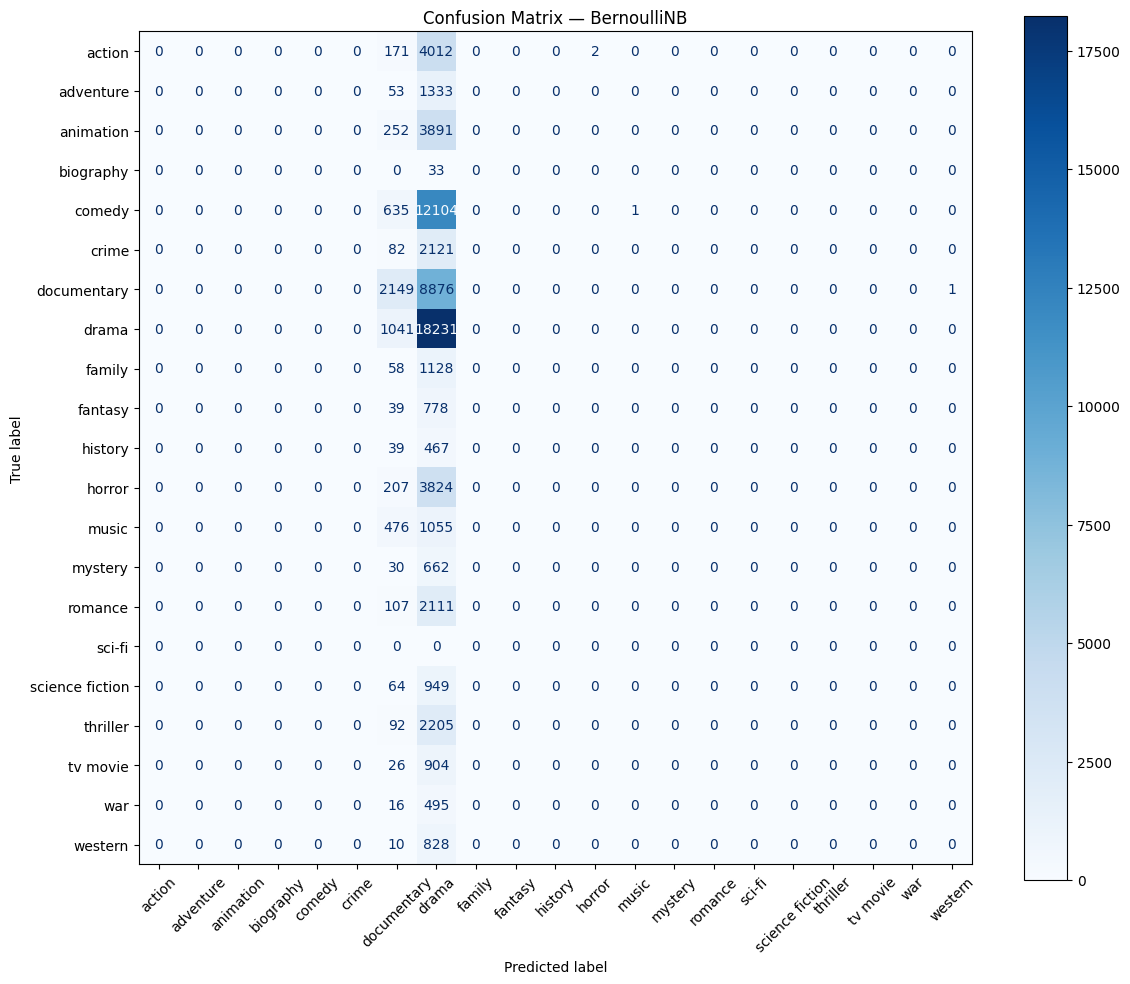

In [113]:
# Confusion matrix for the best model
best_result = results[best_model_name]
fig, ax = plt.subplots(figsize=(12, 10))
cm = confusion_matrix(y_test, best_result['y_pred'], labels=sorted(y.unique()))
disp = ConfusionMatrixDisplay(cm, display_labels=sorted(y.unique()))
disp.plot(ax=ax, xticks_rotation=45, cmap='Blues', values_format='d')
ax.set_title(f'Confusion Matrix — {best_model_name}')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrix_best.png', dpi=150, bbox_inches='tight')
plt.show()

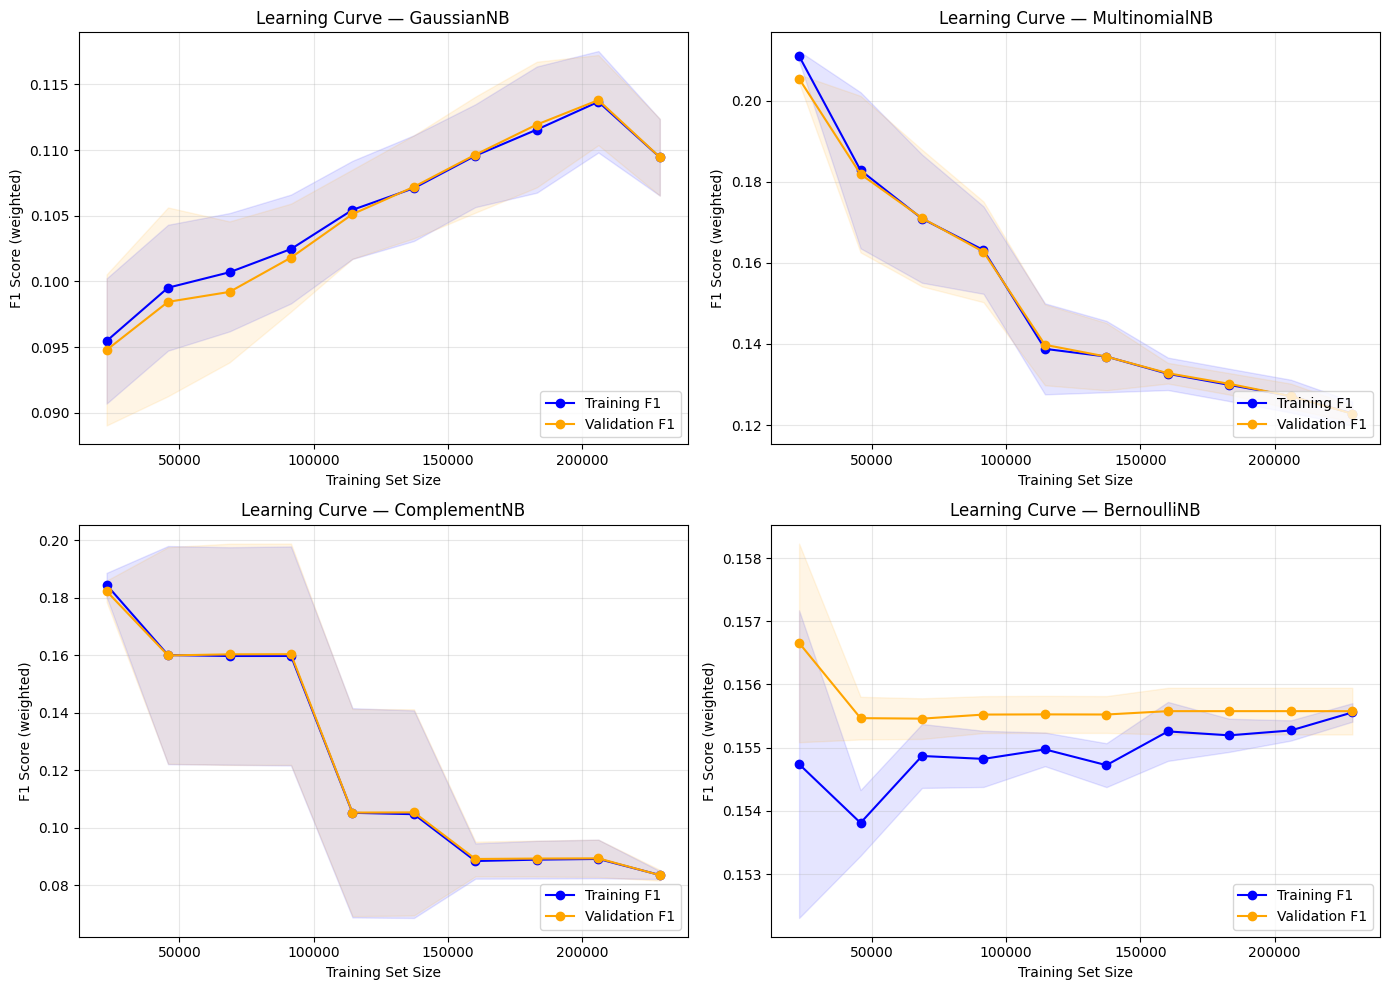

In [114]:
# Learning curves for all models
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (name, r) in enumerate(results.items()):
    ax = axes[idx]
    train_sizes, train_scores, val_scores = learning_curve(
        r['grid'].best_estimator_,
        X_train, y_train,
        cv=5,
        scoring='f1_weighted',
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='orange')
    ax.plot(train_sizes, train_mean, 'o-', color='blue', label='Training F1')
    ax.plot(train_sizes, val_mean, 'o-', color='orange', label='Validation F1')
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('F1 Score (weighted)')
    ax.set_title(f'Learning Curve — {name}')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 17. Save Best Model & Metrics

In [115]:
# Save best model
model_path = RESULTS_DIR / f'best_model_{best_model_name}.joblib'
joblib.dump(results[best_model_name]['grid'].best_estimator_, model_path)
print(f"Best model saved to: {model_path}")

# Save label encoder
le_path = RESULTS_DIR / 'label_encoder.joblib'
joblib.dump(le_target, le_path)
print(f"Label encoder saved to: {le_path}")

# Save summary metrics
summary_df.to_csv(RESULTS_DIR / 'model_comparison.csv')
print(f"Model comparison saved to: {RESULTS_DIR / 'model_comparison.csv'}")

# Save feature list
with open(RESULTS_DIR / 'selected_features.txt', 'w') as f:
    f.write("Top features selected by Mutual Information:\n")
    for feat in top_features:
        mi_val = mi_df[mi_df['feature'] == feat]['mutual_information'].values[0]
        f.write(f"  {feat}: MI={mi_val:.4f}\n")
print(f"Feature list saved to: {RESULTS_DIR / 'selected_features.txt'}")

print(f"\nAll results saved to {RESULTS_DIR}/")
print("Done!")

Best model saved to: results\best_model_BernoulliNB.joblib
Label encoder saved to: results\label_encoder.joblib
Model comparison saved to: results\model_comparison.csv
Feature list saved to: results\selected_features.txt

All results saved to results/
Done!
